# Why use GLIDE ? Evaluate any risk, of any AI system

> **From noisy LLM judges to statistically rigorous quality metrics — in minutes.**

**GLIDE** — the *Generative Label Inference & Debiasing Engine* — combines a small set of expensive true evaluation labels with a large pool of cheap proxy evaluation labels to produce a statistically valid, bias-corrected quality metric. This is necessary because proxy evaluation is generally carried out using LLM judges who are known to disagree between one another. This guide walks through a realistic hallucination-detection scenario end-to-end.

---

**What you will learn:**

- Why LLM-as-Judge metrics are systematically biased
- How to use GLIDE to produce a bias-corrected metric
- How to test that your metric fits your expectations

## The problem: your LLM judge disagrees with your users

Let's assume you run a customer-facing agentic assistant handling thousands of conversations per day.

### The signals

- **Every tenth user** reports incorrect or fabricated information (unacceptable for the management).
- You deploy an LLM judge to measure the hallucination rate. The latter tells you the hallucination rate is **5%**. 

The users and the LLM judge **disagree**. You decide to dig deeper.

### The manual investigation

You budget for **200 manual annotations** — expensive but accurate ground truth.
Annotators find that **~10% of conversations contain a blatant hallucination**.

That is **double what LLM reports**. The judge is *systematically optimistic*.

### The challenge

You now have:
- **2,200 LLM judgements** — cheap and fast, but biased
- **200 human annotations** — accurate, but covering only a small portion of your data

**GLIDE combines both** to produce a reliable, unbiased estimate of the true hallucination rate across all conversations.

![Methodology](https://raw.githubusercontent.com/EmertonData/glide/refs/heads/main/docs/assets/schema-PPI.png)
*A large number of interactions with an AI system are collected. A large subset is labeled by an LLM Judge only and a small subset is labeled by both the LLM judge and human annotators*


In [1]:
%matplotlib inline

import json

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from glide.core.simulated import generate_dataset_binary
from glide.estimators import PPIMeanEstimator, ClassicalMeanEstimator

# ── Colour palette ──────────────────────────────────────────
C_JUDGE = '#E74C3C'   # LLM judge  — red-orange
C_HUMAN = '#2E86AB'   # Human-only — blue
C_GLIDE = '#27AE60'   # GLIDE      — green
C_TRUTH = '#2C3E50'   # True value — dark slate

# ── Global plot style ───────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#FAFAFA',
    'axes.grid'       : True,
    'grid.color'      : '#E5E5E5',
    'grid.linewidth'  : 0.8,
    'axes.titlesize'  : 14,
    'axes.titlepad'   : 14,
    'axes.labelsize'  : 12,
    'xtick.labelsize' : 11,
    'ytick.labelsize' : 11,
})

## Simulating thousands of conversations with a biased judge

`generate_dataset_binary` produces a synthetic dataset that mirrors the scenario above.

Each **record** represents one conversation:

| Field | Present for | Meaning |
|-------|-------------|---------|
| `y_true` | Labeled records only | `1` = hallucination confirmed by human annotator |
| `y_proxy` | All records | `1` = hallucination flagged by the LLM judge |

In [2]:
dataset = generate_dataset_binary(
    n=200,            
    N=2000,            
    true_mean=0.10,   
    proxy_mean=0.05,  
    correlation=0.65, 
    random_seed=42,
)

labeled   = [r for r in dataset if 'y_true'  in r]
unlabeled = [r for r in dataset if 'y_true' not in r]

In [3]:
print(f'Total conversations  : {len(dataset):,}')
print(f'  Manually annotated : {len(labeled):,}')
print(f'  LLM-judged only    : {len(unlabeled):,}')
print()
print('Sample records')
print(f'  labeled   -> {labeled[0]}')
print(f'  unlabeled -> {unlabeled[0]}')

Total conversations  : 2,200
  Manually annotated : 200
  LLM-judged only    : 2,000

Sample records
  labeled   -> {'y_true': 0, 'y_proxy': 0}
  unlabeled -> {'y_proxy': 0}


## Two naive strategies both fail

Two obvious approaches to estimating the true hallucination rate each have a fatal flaw:

**Option A — Trust the judge on all conversations.**  
Precise (large sample), but the judge's systematic bias makes the estimate wrong.

**Option B — Trust only the human annotations.**  
Unbiased, but the 95% confidence interval (CI) is very wide.

GLIDE, introduced in the next section, fixes both problems simultaneously.

In [4]:
# Option A: LLM judge — average proxy labels over all 1,000 conversations
proxy_values_estimation_result = ClassicalMeanEstimator().estimate(dataset=dataset, 
                                                            y_field="y_proxy")
judge_mean = proxy_values_estimation_result.mean
judge_se   = proxy_values_estimation_result.std
judge_lower_bound   = proxy_values_estimation_result.confidence_interval.lower_bound
judge_upper_bound   = proxy_values_estimation_result.confidence_interval.upper_bound

# Option B: human labels only — average over 100 annotated conversations
true_values_estimation_result = ClassicalMeanEstimator().estimate(dataset=dataset, 
                                                            y_field="y_true")
human_mean = true_values_estimation_result.mean
human_se   = true_values_estimation_result.std
human_lower_bound   = true_values_estimation_result.confidence_interval.lower_bound
human_upper_bound   = true_values_estimation_result.confidence_interval.upper_bound


In [5]:
sep = '-' * 62
print(sep)
print(f'{"Method":<34} {"Estimate":>8}   {"95% confidence interval":>16}')
print(sep)
print(
    f'{"LLM Judge only  (n=1,000)":<34} {judge_mean:>7.1%}   '
    f'[{judge_lower_bound:.1%}, {judge_upper_bound:.1%}]'
)
print(
    f'{"Human labels only (n=100)":<34} {human_mean:>7.1%}   '
    f'[{human_lower_bound:.1%}, {human_upper_bound:.1%}]'
)
print(sep)
print(f'{"True rate  (simulation)":<34} {"10.0%":>8}')

--------------------------------------------------------------
Method                             Estimate   95% confidence interval
--------------------------------------------------------------
LLM Judge only  (n=1,000)             5.3%   [4.3%, 6.2%]
Human labels only (n=100)             8.0%   [4.2%, 11.8%]
--------------------------------------------------------------
True rate  (simulation)               10.0%


## The root cause: the LLM judge is systematically biased

The gap is clear: compared to human annotators, the judge consistently under-reports hallucinations on average.

GLIDE's **PPI rectifier** measures this systematic error on the labeled subset, then applies the correction to the remaining conversations:

$$\hat{\mu}_{\text{PPI}} = \underbrace{\bar{y}_{\text{proxy}}^{\,(N)}}_\text{LLM-as-judge} + \underbrace{\left(\bar{y}_{\text{true}} - \bar{y}_{\text{proxy}}^{\,(n)}\right)}_\text{rectifier}$$

where : 

$\bar{y}_{\text{proxy}}^{\,(N)} = $ proxy mean computed on $N$ unlabeled samples

$\bar{y}_{\text{proxy}}^{\,(n)} = $ proxy mean computed on $n$ labeled samples

$\bar{y}_{\text{true}} = $ true mean estimate computed on $n$ labeled samples

The rectifier ($\bar{y}_{\text{true}} - \bar{y}_{\text{proxy}}^{\,(n)}$) equals zero when the judge is perfectly calibrated and grows large when the judge is biased — exactly the situation here.

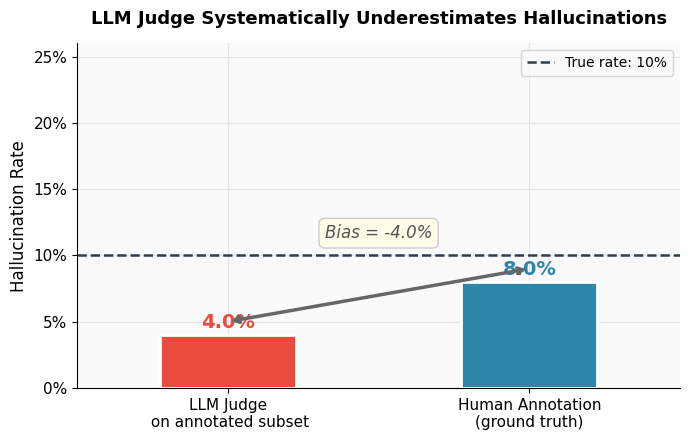

In [6]:
proxy_on_labeled = [r['y_proxy'] for r in labeled]
true_on_labeled  = [r['y_true']  for r in labeled]

p_mean = np.mean(proxy_on_labeled)
t_mean = np.mean(true_on_labeled)
bias   = p_mean - t_mean

fig, ax = plt.subplots(figsize=(7, 4.5))

x_pos      = np.array([0, 1])
bar_vals   = [p_mean, t_mean]
bar_colors = [C_JUDGE, C_HUMAN]
bar_labels = ['LLM Judge\n on annotated subset', 
              'Human Annotation\n(ground truth)']

ax.bar(x_pos, bar_vals, color=bar_colors, width=0.45,
       edgecolor='white', linewidth=2, zorder=3)

for xi, val, c in zip(x_pos, bar_vals, bar_colors):
    ax.text(xi, val + 0.005, f'{val:.1%}',
            ha='center', fontsize=14, fontweight='bold', color=c)

ax.annotate('', xy=(1, t_mean + 0.010), xytext=(0, p_mean + 0.010),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=2.5))
ax.text(0.5, max(bar_vals) + 0.033, f'Bias = {bias:+.1%}',
        ha='center', fontsize=12, color='#555555', fontstyle='italic',
        bbox=dict(boxstyle='round,pad=0.35', 
                  facecolor='#FFFDE7', edgecolor='#CCCCCC'))

ax.axhline(0.10, color=C_TRUTH, linestyle='--', 
           linewidth=1.8, zorder=2, label='True rate: 10%')

ax.set_xticks(x_pos)
ax.set_xticklabels(bar_labels, fontsize=11)
ax.set_ylabel('Hallucination Rate', fontsize=12)
ax.set_title('LLM Judge Systematically Underestimates Hallucinations',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.26)
ax.set_xlim(-0.5, 1.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

## GLIDE corrects the bias using Prediction-Powered Inference

`PPIMeanEstimator` implements Prediction-Powered Inference (PPI)
([Angelopoulos et al., *Science* 2023](https://www.science.org/doi/10.1126/science.adi6000)).

PPI produces a **bias-corrected point estimate** with a **tighter confidence interval (CI)**
than either data source alone, by combining:

- **n** labeled records (with human annotations — expensive ground truth — and LLM judge labels)
- **N** unlabeled records (LLM judge labels — cheap proxies)

The standard error (SE) of the PPI estimate decomposes into two terms:

$$\text{SE}_{\text{PPI}} = \underbrace{\sqrt{\frac{\text{Var}(y_{\text{true}} - y_{\text{proxy}})}{n}}}_{\text{rectifier noise}} + \underbrace{\sqrt{\frac{\text{Var}(y_{\text{proxy}}^{\,N})}{N}}}_{\text{proxy noise}}$$

In [7]:
estimator = PPIMeanEstimator()

ppi_result = estimator.estimate(
    dataset,
    y_true_field='y_true',
    y_proxy_field='y_proxy',
    metric_name='Hallucination Rate',
    confidence_level=0.95,
)

print(ppi_result.summary())

Metric: Hallucination Rate
Point Estimate: 0.089
Confidence Interval (95%): [0.06, 0.12]
Estimator : PPIMeanEstimator
n_true: 200
n_proxy: 2200
Effective Sample Size: 336.0



**When judge and human labels are correlated**, the difference $y_{\text{true}} - y_{\text{proxy}}$ has low variance — the rectifier adds little noise. GLIDE achieves a sizable increase in effective sample size.

### Exporting the Result as JSON

The `InferenceResult` object serializes directly to a plain dictionary, ready for logging, dashboards, or downstream pipelines.

In [8]:
result_dict = {
    'metric_name'         : ppi_result.metric_name,
    'estimator'           : ppi_result.estimator_name,
    'n_labeled'           : ppi_result.n_true,
    'n_total'             : ppi_result.n_proxy,
    'point_estimate'      : round(ppi_result.confidence_interval.mean, 4),
    'confidence_interval' : {
        'lower'            : round(ppi_result.confidence_interval.lower_bound, 4),
        'upper'            : round(ppi_result.confidence_interval.upper_bound, 4),
        'confidence_level' : ppi_result.confidence_interval.confidence_level,
        },
    'effective_sample_size' : ppi_result.effective_sample_size,
    'standard_error'      : round(ppi_result.std, 4),
}

print(json.dumps(result_dict, indent=2))

{
  "metric_name": "Hallucination Rate",
  "estimator": "PPIMeanEstimator",
  "n_labeled": 200,
  "n_total": 2200,
  "point_estimate": 0.0894,
  "confidence_interval": {
    "lower": 0.0604,
    "upper": 0.1185,
    "confidence_level": 0.95
  },
  "effective_sample_size": 336,
  "standard_error": 0.0148
}


## GLIDE Delivers an Unbiased Estimate at Low Cost

The plot below compares **point estimates** and **95% confidence intervals** for all three methods against the true hallucination rate (dashed line):

- **LLM judge**: very narrow confidence interval, but wrong.
- **Human-only**: unbiased, but the confidence interval is very wide.
- **GLIDE**: unbiased *and* narrow — the accuracy of human labels combined with the precision of many proxy judgements.

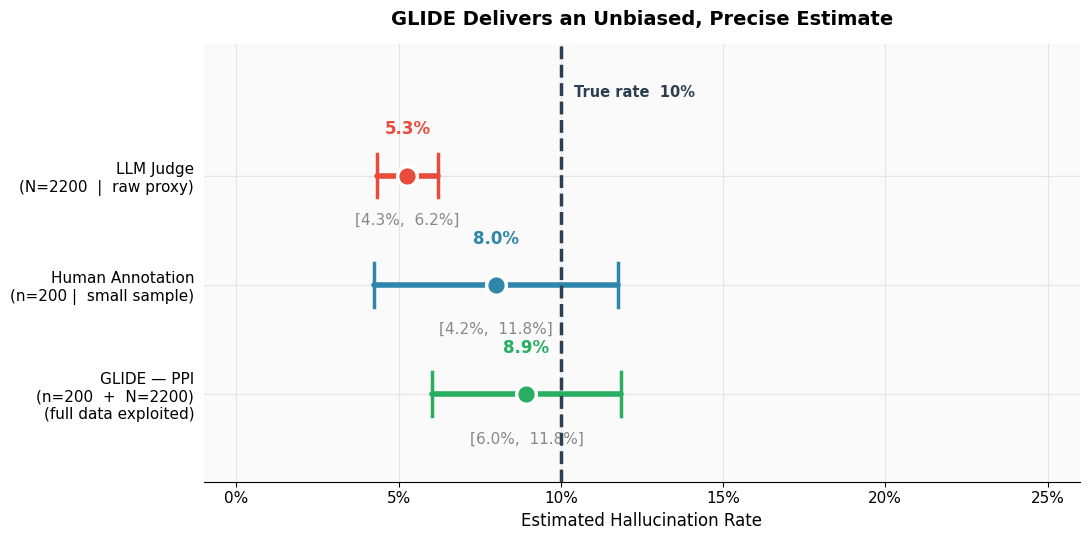

In [9]:
TRUE_RATE = 0.10

estimates = [
    (
        f'LLM Judge\n(N={ppi_result.n_proxy}  |  raw proxy)',
        judge_mean,
        judge_lower_bound,
        judge_upper_bound,
        C_JUDGE,
    ),
    (
        f'Human Annotation\n(n={ppi_result.n_true} |  small sample)',
        human_mean,
        human_lower_bound,
        human_upper_bound,
        C_HUMAN,
    ),
    (
        f'GLIDE — PPI\n(n={ppi_result.n_true}  +  N={ppi_result.n_proxy})\n(full data exploited)',
        ppi_result.mean,
        ppi_result.confidence_interval.lower_bound,
        ppi_result.confidence_interval.upper_bound,
        C_GLIDE,
    ),
]

fig, ax = plt.subplots(figsize=(11, 5.5))
y_pos = [2, 1, 0]

for y, (label, mean, lo, hi, color) in zip(y_pos, estimates):
    # Confidence interval line
    ax.plot([lo, hi], [y, y], color=color, linewidth=4,
            solid_capstyle='round', zorder=3)
    # Cap marks
    for xc in [lo, hi]:
        ax.plot([xc, xc], [y - 0.2, y + 0.2],
                color=color, linewidth=2.5, zorder=3)
    # Point estimate
    ax.scatter(mean, y, s=200, color=color, zorder=5,
               edgecolors='white', linewidths=2.5)
    # Value label above
    ax.text(mean, y + 0.34, f'{mean:.1%}',
            ha='center', va='bottom', fontsize=12,
            color=color, fontweight='bold')
    # Confidence interval bounds below
    ax.text(mean, y - 0.34, f'[{lo:.1%},  {hi:.1%}]',
            ha='center', va='top', fontsize=11, color='#888888')

# True value
ax.axvline(TRUE_RATE, color=C_TRUTH, 
           linestyle='--', linewidth=2.5, zorder=4)
ax.text(TRUE_RATE + 0.004, 2.72, 'True rate  10%',
        color=C_TRUTH, fontsize=10.5, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels([e[0] for e in estimates], fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_xlabel('Estimated Hallucination Rate', fontsize=12)
ax.set_title('GLIDE Delivers an Unbiased, Precise Estimate',
             fontsize=14, fontweight='bold')
ax.set_xlim(-0.01, 0.26)
ax.set_ylim(-0.8, 3.2)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

## Testing whether the hallucination rate is within acceptable limits

GLIDE's estimate enables a formal hypothesis test: is the true hallucination rate significantly higher than 5% ?

$$H_0 : \mu = 5\% \qquad H_1 : \mu > 5\%$$

Is our system's hallucination rate sufficiently below the business tolerance of 5% to deploy safely ?

Without GLIDE, we can use the LLM judge estimate only which gives us a misleading confidence interval close to 5% making it unlikely that we would reject the null hypothesis. On ther other hand, the confidence interval obtained thanks to human annotators only is wide and leads to conservative decisions.

GLIDE combines both sources using a statistical method which allows us to perform accurate hypothesis testing.

In [10]:
z_stat, p_value, _ = ppi_result.confidence_interval.test_null_hypothesis(
    h0_value=0.05,       # LLM judge's claimed rate
    alternative='larger' # H1: true rate > 5%
)

sep = '-' * 48
print('Hypothesis test')
print(sep)
print('H0 : hallucination rate = 5%   (LLM says so)')
print('H1 : hallucination rate > 5%   (users complain!)')
print()
print(f'z-statistic : {z_stat:.2f}')
print(f'p-value     : {p_value:.10f}')
print()
if p_value < 0.05:
    print('Decision  : Given the p-value is lower than our threshold (p-value < 0.05),' \
    ' we reject H0 at the 5% level.')
    print('=> The true hallucination rate is significantly above 5%.')
else:
    print('Decision  : Given the p-value is higher than our threshold (p-value >= 0.05), ' \
    ' we cannot reject H0 at the 5% level.')

Hypothesis test
------------------------------------------------
H0 : hallucination rate = 5%   (LLM says so)
H1 : hallucination rate > 5%   (users complain!)

z-statistic : 2.66
p-value     : 0.0039285497

Decision  : Given the p-value is lower than our threshold (p-value < 0.05), we reject H0 at the 5% level.
=> The true hallucination rate is significantly above 5%.


## Summary: GLIDE combines accuracy and precision

| | LLM Judge | Human-only | **GLIDE** |
|-|-----------|-----------|-----------|
| Sample size | 2,000 | 200 | 2,200 |
| Unbiased estimate | ❌ | ✅ | ✅ |
| Narrow confidence interval | 🟠 *(misleading)* | ❌ | ✅ |
| Labeling cost | Low | **High** | Small |

**Key takeaways:**

1. **LLM judges are biased.** A narrow confidence interval around the wrong value is worse than useless — it gives false confidence.

2. **200 human annotations is all you need.** The rectifier uses information from 2200 cheap proxy labels to shrink the confidence interval by a large amount compared to human-only estimation.

3. **PPI efficiency relies on sample size and LLM-judge quality.** To shrink the confidence interval further, you can invest in either more human annotations or a better aligned LLM-judge.

---

*Want to go further? Knowing precisely what you are measuring — and with what uncertainty — is the essential first step into LLM alignment, guardrailing, and agentic workflows with self-evaluation loops. These next steps will soon be included in GLIDE.* 